# Thai Parenting Style Text Classification

## ภาพรวม
โน้ตบุ๊กนี้ใช้สำหรับจำแนกประเภท **Thai Parenting Style** ออกเป็น 5 ประเภท:
- **Authoritarian** (เผด็จการ)
- **Authoritative** (ประชาธิปไตย)
- **Neglectful** (เลี้ยงดูแบบละเลย)
- **Permissive** (ปล่อยปละละเลย)
- **Uncertain** (ไม่แน่ชัด)

ใช้เทคนิค Machine Learning และ Deep Learning หลากหลายวิธี:
1. **TF-IDF + POS Tagging + Linear SVM**
2. **WangchanBERTa Embedding + Linear SVM**
3. **WangchanBERTa Embedding + BiLSTM**
4. **Fine-tuned PhayaThaiBERT** (Sequence Classification)

---

## ขั้นตอนการรัน

### 1. ติดตั้ง Dependencies
รันเซลล์แรกเพื่อติดตั้งไลบรารีที่จำเป็น

### 2. โหลดและเตรียมข้อมูล
- โหลดไฟล์ `thai_parenting_dataset.csv`
- แปลง label เป็นตัวเลข
- แบ่งข้อมูลเป็น train/test set

### 3. Data Augmentation (ถ้ามี)
หากต้องการเพิ่มจำนวนข้อมูล สามารถใช้ `th_aug.py`

### 4. เทรนโมเดล
รันเซลล์ตามลำดับสำหรับแต่ละวิธี

### 5. ประเมินผล
ผลลัพธ์จะแสดง Accuracy, Classification Report, Confusion Matrix และ ROC-AUC

---

## หมายเหตุสำคัญ
-  **Runtime**: แนะนำใช้ GPU สำหรับเทรน BERT models
-  **Memory**: หากเจอ OOM ให้ลด batch size
-  **Hyperparameters**: สามารถปรับค่าได้ตามต้องการ

---

**เริ่มต้นใช้งาน**: รันเซลล์ตามลำดับจากบนลงล่าง

In [ ]:
import pandas as pd
from google.colab import files # ต้องมี import นี้สำหรับการอัปโหลดไฟล์ใน Colab
import io # สำหรับอ่านไฟล์ที่อัปโหลด

## 1. การอัปโหลดไฟล์ CSV และอ่านข้อมูล 📤
print("Please upload your labeled dataset CSV file)")
# ใช้ files.upload() เพื่อให้อัปโหลดไฟล์ และเก็บผลลัพธ์ใน uploaded_labeled
uploaded_labeled = files.upload()

# ดึงชื่อไฟล์ที่ถูกอัปโหลด
labeled_filename = list(uploaded_labeled.keys())[0]

# อ่านไฟล์ CSV ที่อัปโหลดเข้าสู่ DataFrame
df = pd.read_csv(labeled_filename)

## 2. กำหนด Mapping ระหว่าง label ข้อความกับตัวเลข
label_map = {
    "Authoritarian": 0,
    "Authoritative": 1,
    "Neglectful": 2,
    "Permissive": 3,
    "Uncertain" : 4
}

## 3. แมป label จากข้อความเป็นตัวเลข
# ตรวจสอบว่าคอลัมน์ "Label" มีอยู่ใน DataFrame ก่อนดำเนินการ map
if "Label" in df.columns:
    df["label"] = df["Label"].map(label_map)
    print(f"\n  Mapping 'Label' column complete. New column 'label' created.")
else:
    print("\n  Error: The uploaded CSV file must contain a column named 'Label'.")

## 4. บันทึกไฟล์ใหม่
output_filename = "thai_parenting_label.csv"
df.to_csv(output_filename, index=False, encoding="utf-8-sig")

print(f"\n New processed file saved as: **{output_filename}**")

# ถ้าต้องการดาวน์โหลดไฟล์ผลลัพธ์กลับไปยังเครื่อง:
# files.download(output_filename)
# print(f"File {output_filename} is ready for download.")

## Data Augmentation (เพิ่มข้อมูล)

เซลล์นี้ใช้ **th_aug.py** เพื่อสร้างข้อมูลเทียมเพิ่มเติมด้วยเทคนิค NLP ขั้นสูง 4 วิธี:

โดยอัพโหลดไฟล์ **th_aug.py**
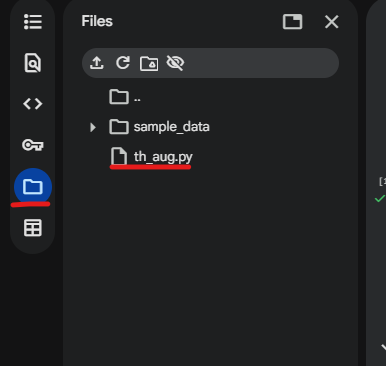
### คำอธิบาย Parameters

```bash
!python th_aug.py \
  --input thai_parenting_test.csv \
  --output thai_parenting_aug_ori.csv \
  --n_aug 8 \
  --techniques sr,bt,c1,rd \
  --use_bert True \
  --use_bt True
```

| Parameter | ความหมาย | ค่าเริ่มต้น |
|-----------|---------|----------|
| `--input` | ไฟล์ CSV ต้นทางที่ต้องการ augment | `thai_parenting_test.csv` |
| `--output` | ไฟล์ผลลัพธ์ที่บันทึก (ข้อมูลต้นทาง + ข้อมูล augment) | `thai_parenting_aug_ori.csv` |
| `--n_aug` | จำนวน augmented samples ต่อ 1 ข้อมูล | `8` (สร้าง 8 แบบต่อข้อความ) |
| `--techniques` | เทคนิคที่ใช้ (sr, bt, ci, rd) | `sr,bt,ci,rd` (ใช้ทั้ง 4 วิธี) |
| `--use_bert` | ใช้ ThaiBERT สำหรับ Contextual Insertion | `True` |
| `--use_bt` | ใช้ Back Translation (TH→EN→TH) | `True` |

### เทคนิค Augmentation ทั้ง 4 วิธี

1. **sr** (Synonym Replacement) - แทนที่คำด้วยคำใกล้ความโดยใช้ Thai WordNet
2. **bt** (Back Translation) - แปล TH→EN→TH เพื่อสร้าง paraphrase ที่หลากหลาย
3. **ci** (Contextual Insertion) - แทรกคำใหม่ที่เหมาะสมด้วย WangchanBERTa MLM
4. **rd** (Random Deletion) - ลบคำบางคำแบบสุ่มเพื่อสร้างความหลากหลาย

### ผลลัพธ์
- ไฟล์ผลลัพธ์จะมีข้อมูลต้นทาง + augmented data ทั้งหมด
- มีการ deduplication อัตโนมัติเพื่อลบข้อมูลซ้ำ

In [ ]:
!python th_aug.py \
  --input thai_parenting_test.csv \
  --output thai_parenting_aug_ori.csv \
  --n_aug 8 \
  --techniques sr,bt,ci,rd \
  --use_bert True \
  --use_bt True


python3: can't open file '/content/th_aug.py': [Errno 2] No such file or directory


## Complete Thai Parenting Style Text Classification Pipeline

### ภาพรวมของเซลล์นี้

เซลล์นี้เป็น Complete End-to-End Pipeline ที่รวมทุกขั้นตอนการจำแนกประเภท Thai Parenting Style ไว้ในโค้ดเดียว ครบทุกขั้นตอนตั้งแต่การประมวลผลข้อมูล การเทรนโมเดล 4 แบบ ไปจนถึงการเปรียบเทียบผลลัพธ์

### การเตรียมความพร้อม

**ขั้นตอนที่ 1: ตั้งค่า Runtime**
- ไปที่ Runtime > Change runtime type
- เลือก Hardware accelerator เป็น GPU หรือ TPU
- คลิก Save
- ข้อแนะนำ: GPU จำเป็นสำหรับการเทรน BERT models เพื่อความเร็วและประสิทธิภาพ

**ขั้นตอนที่ 2: เตรียมไฟล์ข้อมูล**

จะต้องเตรียมไฟล์ 2 ไฟล์:

1. **LINE Chat Backup File** (ไฟล์ .txt)
   - Export จากแอป LINE
   - Format: ข้อความแชทแบบ LINE standard format
   - ใช้สำหรับ: Parse และทำความสะอาดข้อความ

2. **Labeled Dataset CSV**
   - ต้องมีคอลัมน์: `text` และ `label`
   - คอลัมน์ `text`: ข้อความที่ต้องการจำแนก (string)
   - คอลัมน์ `label`: ตัวเลข 0-4 (integer) ที่แทนประเภท parenting style
     - 0 = Authoritarian (เผด็จการ)
     - 1 = Authoritative (ประชาธิปไตย)
     - 2 = Neglectful (เลี้ยงดูแบบละเลย)
     - 3 = Permissive (ปล่อยปละละเลย)
     - 4 = Uncertain (ไม่แน่ชัด)
   - Encoding: UTF-8

### วิธีการรันเซลล์นี้

**ขั้นตอนที่ 1: คลิก Run Cell**
- คลิกปุ่ม Play ที่มุมซ้ายของเซลล์
- หรือกด Ctrl+Enter (Windows/Linux) หรือ Cmd+Enter (Mac)

**ขั้นตอนที่ 2: รอติดตั้ง Dependencies**
- โปรแกรมจะติดตั้งไลบรารีที่จำเป็นก่อน:
  - pythainlp (สำหรับ tokenization และ POS tagging)
  - transformers (สำหรับ BERT models)
  - torch (PyTorch framework)
  - tensorflow (สำหรับ BiLSTM)
  - scikit-learn (สำหรับ ML models)
- ใช้เวลาประมาณ 2-3 นาที

**ขั้นตอนที่ 3: อัปโหลดไฟล์ LINE Chat**
- เมื่อโปรแกรมแสดงข้อความ "Please upload your LINE chat backup file (.txt):"
- คลิกปุ่ม "Choose Files"
- เลือกไฟล์ LINE chat backup ที่เตรียมไว้
- รอให้โปรแกรม parse และทำความสะอาดข้อมูล

**ขั้นตอนที่ 4: อัปโหลดไฟล์ Labeled Dataset**
- เมื่อโปรแกรมแสดงข้อความ "Please upload your labeled dataset CSV file:"
- คลิกปุ่ม "Choose Files"
- เลือกไฟล์ CSV ที่มี label แล้ว
- โปรแกรมจะโหลดและตรวจสอบข้อมูล

**ขั้นตอนที่ 5: รอการเทรนโมเดลทั้ง 4 แบบ**

โปรแกรมจะเทรนโมเดลตามลำดับดังนี้:

1. **TF-IDF + POS Tagging + Linear SVM** (ใช้เวลา: 2-5 นาที)
   - Extract features ด้วย TF-IDF และ POS tags
   - Train Linear SVM
   - ทำ 10-fold Cross Validation
   - คำนวณ ROC-AUC

2. **WangchanBERTa Embedding + Linear SVM** (ใช้เวลา: 3-5 นาที)
   - โหลด WangchanBERTa model
   - Extract [CLS] embeddings
   - Train Linear SVM บน embeddings
   - ทำ 10-fold Cross Validation
   - คำนวณ ROC-AUC

3. **WangchanBERTa Embedding + BiLSTM** (ใช้เวลา: 5-8 นาที)
   - ใช้ WangchanBERTa embeddings
   - Train Bidirectional LSTM (TensorFlow/Keras)
   - Early stopping ป้องกัน overfitting
   - คำนวณ ROC-AUC
   - บันทึกโมเดลเป็น `bilstm_wangchanberta_model.h5`

4. **Fine-tuned PhayaThaiBERT** (ใช้เวลา: 10-15 นาที)
   - โหลด PhayaThaiBERT model
   - Fine-tune สำหรับ sequence classification
   - ใช้ Hugging Face Trainer
   - คำนวณ ROC-AUC
   - บันทึกโมเดลเป็น `./saved_phayathai_model/`

### ผลลัพธ์ที่จะแสดง

**ระหว่างการรัน:**
- ข้อความแจ้งสถานะการติดตั้ง dependencies
- จำนวนข้อความที่ parse ได้
- จำนวนข้อมูลหลังทำความสะอาด
- Label distribution
- Training progress แต่ละโมเดล
- Accuracy และ metrics ของแต่ละโมเดล

**สำหรับแต่ละโมเดล จะแสดง:**
- Accuracy (ความแม่นยำ)
- ROC-AUC Macro (ค่าเฉลี่ย ROC-AUC ทุก class)
- ROC-AUC Micro (ROC-AUC แบบรวม)
- ROC-AUC Weighted (ROC-AUC ถ่วงน้ำหนักตามจำนวนตัวอย่าง)
- Classification Report (Precision, Recall, F1-score แต่ละ class)
- Training Time (เวลาในการเทรน)

**สำหรับ SVM models เพิ่มเติม:**
- 10-fold CV Accuracy (mean ± std)
- 10-fold CV ROC-AUC Weighted (mean ± std)

**ผลลัพธ์สุดท้าย:**
- ตารางเปรียบเทียบทุกโมเดล (เรียงตาม Accuracy)
- แสดงข้อมูลโมเดลที่ดีที่สุด
- บันทึกตารางเปรียบเทียบเป็น `model_comparison_results_with_cv.csv`

### ไฟล์ Output ที่จะได้

1. `line_cleaned_data.csv` - ข้อความ LINE ที่ทำความสะอาดแล้ว
2. `labeled_data_tokenized.csv` - ข้อมูล labeled ที่ tokenize แล้ว
3. `bilstm_wangchanberta_model.h5` - โมเดล BiLSTM ที่เทรนเสร็จ
4. `./saved_phayathai_model/` - โมเดล PhayaThaiBERT ที่ fine-tune เสร็จ
5. `model_comparison_results_with_cv.csv` - ตารางเปรียบเทียบผลลัพธ์ทุกโมเดล

### การแก้ปัญหาที่พบบ่อย

**ปัญหา: CUDA Out of Memory (OOM)**
- แก้ไข: ลดค่า `MAX_LENGTH_BERT` จาก 128 เป็น 64
- หรือ: เปลี่ยน batch size ในส่วน PhayaThaiBERT training

**ปัญหา: Import Error**
- แก้ไข: รันเซลล์ใหม่อีกครั้ง จะติดตั้ง dependencies ใหม่

**ปัญหา: File Not Found**
- ตรวจสอบว่าไฟล์ CSV มีคอลัมน์ `text` และ `label`
- ตรวจสอบว่า label เป็นตัวเลข 0-4

**ปัญหา: Encoding Error**
- บันทึกไฟล์ CSV ด้วย encoding UTF-8
- ใน Excel: Save As > CSV UTF-8

### ข้อควรระวัง

- ต้องใช้ GPU runtime สำหรับ BERT models
- ไฟล์ labeled dataset ต้องมีคอลัมน์ที่ถูกต้อง
- label ต้องเป็นตัวเลข 0-4 เท่านั้น
- ไม่ควรปิดหน้าต่างระหว่างการรัน
- หากมี error ให้อ่านข้อความ error และแก้ไขตามที่แนะนำ

In [ ]:
# ========================================================================================================
# Thai Parenting Style Text Classification Pipeline
# Methods:
#   1) TF-IDF + POS Tagging + Linear SVM
#   2) WangchanBERTa Embedding + Linear SVM
#   3) WangchanBERTa Embedding + BiLSTM
#   4) Fine-tuned PhayaThaiBERT (Sequence Classification)
#   + 10-fold Cross Validation (SVM models)
#   + ROC-AUC for ALL models
# ========================================================================================================

import sys
import subprocess
import re
import time
import logging
from typing import List, Dict
from pathlib import Path

import numpy as np
import pandas as pd

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(message)s'
)
logger = logging.getLogger(__name__)

# ======================== Dependencies Installation ========================
print("Installing required packages...")
subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "pythainlp",
        "transformers",
        "torch",
        "tensorflow",
        "datasets",
        "scikit-learn",
    ]
)
print("Installation completed.\n")

# ======================== Import Libraries ========================
from pythainlp import word_tokenize
from pythainlp.tag import pos_tag
from pythainlp.corpus import thai_stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize

import torch
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping

from transformers import Trainer, TrainingArguments
from datasets import Dataset

from google.colab import files

# ======================== Configuration ========================
CONFIG = {
    "WANGCHAN_MODEL": "airesearch/wangchanberta-base-att-spm-uncased",
    "PHAYATHAI_MODEL": "Pavarissy/phayathaibert-thainer",
    "MAX_LENGTH_BERT": 128,
    "MIN_TEXT_LENGTH": 5,
    "TEST_SIZE": 0.2,
    "RANDOM_STATE": 42,
    "N_FOLDS": 10,
}

NORMALIZATION_MAP = {
    "เดะ": "เดี๋ยว",
    "งับ": "ครับ",
    "ค้าบ": "ครับ",
    "คร้าบ": "ครับ",
    "มั้ย": "ไหม",
    "ป่ะ": "หรือเปล่า",
    "ฟะ": "ฟัน",
    "นะจะ": "ค่ะ",
    "นะค่ะ": "ค่ะ",
}

# ======================== Utility Classes ========================

class MetricsCalculator:
    """Calculate classification metrics including ROC-AUC and CV scores."""

    @staticmethod
    def calculate_multiclass_roc_auc(y_true, y_pred_proba, num_classes: int) -> Dict[str, float]:
        """Calculate ROC-AUC (macro/micro/weighted) for multiclass."""
        y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
        try:
            macro_auc = roc_auc_score(y_true_bin, y_pred_proba, multi_class="ovr", average="macro")
            micro_auc = roc_auc_score(y_true_bin, y_pred_proba, multi_class="ovr", average="micro")
            weighted_auc = roc_auc_score(y_true_bin, y_pred_proba, multi_class="ovr", average="weighted")
            return {
                "roc_auc_macro": macro_auc,
                "roc_auc_micro": micro_auc,
                "roc_auc_weighted": weighted_auc,
            }
        except Exception as e:
            logger.warning(f"ROC-AUC calculation failed: {e}")
            return {
                "roc_auc_macro": 0.0,
                "roc_auc_micro": 0.0,
                "roc_auc_weighted": 0.0,
            }

    @staticmethod
    def cross_validate_svm(
        X,
        y,
        n_folds: int,
        random_state: int,
        description: str,
    ) -> Dict[str, float]:
        """
        Run Stratified K-Fold CV for Linear SVM (with probability=True) and return mean metrics.
        Uses:
          - accuracy
          - roc_auc_ovr_weighted (multiclass ROC-AUC)
        """
        logger.info(f"\n[10-fold Cross Validation] {description}")
        logger.info("-" * 100)

        cv = StratifiedKFold(
            n_splits=n_folds,
            shuffle=True,
            random_state=random_state,
        )

        base_svm = SVC(
            kernel="linear",
            probability=True,
            random_state=random_state,
        )

        # Accuracy
        cv_acc = cross_val_score(
            base_svm,
            X,
            y,
            cv=cv,
            scoring="accuracy",
            n_jobs=-1,
        )

        # ROC-AUC (weighted OVR)
        cv_auc = cross_val_score(
            base_svm,
            X,
            y,
            cv=cv,
            scoring="roc_auc_ovr_weighted",
            n_jobs=-1,
        )

        mean_acc = cv_acc.mean()
        std_acc = cv_acc.std()
        mean_auc = cv_auc.mean()
        std_auc = cv_auc.std()

        logger.info(f"CV Accuracy (mean ± std): {mean_acc:.4f} ± {std_acc:.4f}")
        logger.info(f"CV ROC-AUC (weighted OVR, mean ± std): {mean_auc:.4f} ± {std_auc:.4f}")

        return {
            "cv_accuracy_mean": mean_acc,
            "cv_accuracy_std": std_acc,
            "cv_roc_auc_weighted_mean": mean_auc,
            "cv_roc_auc_weighted_std": std_auc,
        }

class TextCleaner:
    """Comprehensive Thai text cleaning pipeline."""

    def __init__(self):
        self.stopwords = set(thai_stopwords())

    def normalize_informal(self, text: str) -> str:
        for informal, standard in NORMALIZATION_MAP.items():
            text = text.replace(informal, standard)
        return text

    def remove_repeated_chars(self, text: str, max_repeat: int = 2) -> str:
        pattern = r"([\u0E00-\u0E7F])\1{" + str(max_repeat) + ",}"
        text = re.sub(pattern, r"\1" * max_repeat, text)
        return text

    def basic_clean(self, text: str) -> str:
        text = re.sub(r"\[รูป\]|\[สติกเกอร์\]|\[วิดีโอ\]|\[ระบบ\]|\[ผู้ถูกลบบัญชี\]", "", text)
        text = re.sub(r"http\S+|www\.\S+|[\w\.-]+@[\w\.-]+\.\w+", "", text)
        text = re.sub(r"@\S+", "", text)
        text = re.sub(r"[^\u0E00-\u0E7F\s]", "", text)
        text = re.sub(r"\s+", " ", text).strip()
        return text

    def remove_stopwords(self, text: str) -> str:
        tokens = word_tokenize(text, engine="newmm")
        tokens = [t for t in tokens if t not in self.stopwords]
        return " ".join(tokens)

    def remove_short_tokens(self, text: str, min_length: int = 2) -> str:
        tokens = word_tokenize(text, engine="newmm")
        tokens = [t for t in tokens if len(t) >= min_length]
        return " ".join(tokens)

    def remove_unlikely_long_tokens(self, text: str, max_length: int = 20) -> str:
        tokens = word_tokenize(text, engine="newmm")
        tokens = [t for t in tokens if len(t) <= max_length]
        return " ".join(tokens)

    def clean(self, text: str) -> str:
        text = self.normalize_informal(text)
        text = self.remove_repeated_chars(text, max_repeat=2)
        text = self.basic_clean(text)
        if not text:
            return ""
        text = self.remove_stopwords(text)
        if not text:
            return ""
        text = self.remove_short_tokens(text, min_length=2)
        if not text:
            return ""
        text = self.remove_unlikely_long_tokens(text, max_length=20)
        return text

class LineParser:
    """Parse LINE backup chat file."""

    @staticmethod
    def parse(filepath: str) -> List[Dict[str, str]]:
        with open(filepath, "r", encoding="utf-8") as f:
            lines = f.readlines()

        messages = []
        date_pattern = re.compile(r"^(จ\.|อ\.|พ\.|พฤ\.|ศ\.|ส\.|อา\.)")
        msg_pattern = re.compile(r"^(\d{1,2}:\d{2})\t(.+?)\t(.*)$")

        for line in lines:
            line = line.strip()
            if not line or date_pattern.match(line):
                continue

            match = msg_pattern.match(line)
            if match:
                _, sender, text = match.groups()
                messages.append({"sender": sender.strip(), "text": text.strip()})

        return messages

# ======================== STEP 1: Parse LINE Chat ========================
print("=" * 100)
print("Complete Thai Parenting Style Text Classification System")
print("Comparing Traditional ML, Deep Learning (LSTM), and Fine-tuned BERT")
print("=" * 100)
print()

logger.info("[STEP 1] Parsing LINE chat file...")
logger.info("-" * 100)

print("Please upload your LINE chat backup file (.txt):")
uploaded = files.upload()
line_filename = list(uploaded.keys())[0]

messages = LineParser.parse(line_filename)
logger.info(f"Total messages parsed: {len(messages)}\n")

# ======================== STEP 2: Data Cleaning ========================
logger.info("[STEP 2] Cleaning text data...")
logger.info("-" * 100)

cleaner = TextCleaner()
df_line = pd.DataFrame(messages)
df_line["clean_text"] = df_line["text"].apply(cleaner.clean)
df_line = df_line[df_line["clean_text"].str.len() > CONFIG["MIN_TEXT_LENGTH"]].copy()
df_line = df_line.dropna(subset=["clean_text"])

logger.info(f"Messages after cleaning: {len(df_line)}")
df_line[["sender", "clean_text"]].to_csv(
    "line_cleaned_data.csv", index=False, encoding="utf-8-sig"
)
logger.info("Saved: line_cleaned_data.csv\n")

# ======================== STEP 3: Load Labeled Dataset (UPLOAD METHOD) ========================
logger.info("[STEP 3] Loading labeled training dataset...")
logger.info("-" * 100)

print("Please upload your labeled dataset CSV file (must have 'text' and 'label' columns):")
uploaded_labeled = files.upload()
labeled_filename = list(uploaded_labeled.keys())[0]

try:
    df_labeled = pd.read_csv(labeled_filename)
    df_labeled["label"] = df_labeled["label"].astype(int)
    logger.info(f"Labeled dataset loaded: {len(df_labeled)} samples\n")
    logger.info("Label distribution:")
    print(df_labeled["label"].value_counts().sort_index())
except Exception as e:
    raise Exception(f"Error loading labeled file: {e}")

df_labeled["text_clean"] = df_labeled["text"].astype(str).apply(cleaner.clean)
df_labeled = df_labeled[df_labeled["text_clean"].str.len() > CONFIG["MIN_TEXT_LENGTH"]].copy()
df_labeled = df_labeled.dropna(subset=["text_clean"])

original_count = len(df_labeled)
df_labeled.drop_duplicates(subset=["text_clean", "label"], inplace=True)
removed_duplicates = original_count - len(df_labeled)

logger.info(f"After cleaning and deduplication: {len(df_labeled)} samples\n")

# ======================== STEP 4: Tokenization ========================
logger.info("[STEP 4] Tokenization...")
logger.info("-" * 100)

def tokenize_thai(text: str) -> List[str]:
    return word_tokenize(text, engine="newmm")

df_labeled["tokens"] = df_labeled["text_clean"].apply(tokenize_thai)
df_labeled["tokens_text"] = df_labeled["tokens"].apply(lambda x: " ".join(x))
df_labeled["num_tokens"] = df_labeled["tokens"].apply(len)

logger.info("Tokenization completed")
df_labeled.to_csv("labeled_data_tokenized.csv", index=False, encoding="utf-8-sig")
logger.info("Saved: labeled_data_tokenized.csv\n")

# ======================== STEP 5: Train-Test Split ========================
logger.info("[STEP 5] Splitting dataset...")
logger.info("-" * 100)

texts = df_labeled["text_clean"].tolist()
labels = df_labeled["label"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=CONFIG["TEST_SIZE"],
    random_state=CONFIG["RANDOM_STATE"],
    stratify=labels,
)

num_classes = len(set(labels))
logger.info(f"Train: {len(X_train_text)}, Test: {len(X_test_text)}")
logger.info(f"Number of classes: {num_classes}\n")

results = []

# ======================== APPROACH 1: TF-IDF + POS + SVM ========================
print("=" * 100)
print("APPROACH 1: TF-IDF + POS Tagging + Linear SVM")
print("=" * 100)

def tokenize_with_pos(text: str) -> str:
    tokens = word_tokenize(text, engine="newmm")
    tagged = pos_tag(tokens, engine="perceptron")
    word_pos = [f"{word}_{tag}" for word, tag in tagged]
    return " ".join(word_pos)

logger.info("\nGenerating POS-tagged tokens...")
train_tokens_pos = [tokenize_with_pos(text) for text in X_train_text]
test_tokens_pos = [tokenize_with_pos(text) for text in X_test_text]

tfidf_pos = TfidfVectorizer(max_features=3000)
X_train_tfidf_pos = tfidf_pos.fit_transform(train_tokens_pos).toarray()
X_test_tfidf_pos = tfidf_pos.transform(test_tokens_pos).toarray()

print(f"TF-IDF (with POS) shape: {X_train_tfidf_pos.shape}\n")

svm_pos = SVC(
    kernel="linear",
    random_state=CONFIG["RANDOM_STATE"],
    probability=True,
)

logger.info("[Training Linear SVM on TF-IDF + POS]")
logger.info("-" * 100)
start_time = time.time()
svm_pos.fit(X_train_tfidf_pos, y_train)
train_time = time.time() - start_time

y_pred_pos = svm_pos.predict(X_test_tfidf_pos)
y_pred_proba_pos = svm_pos.predict_proba(X_test_tfidf_pos)
acc_pos = accuracy_score(y_test, y_pred_pos)

roc_metrics_pos = MetricsCalculator.calculate_multiclass_roc_auc(
    y_test, y_pred_proba_pos, num_classes
)

logger.info(f"Accuracy: {acc_pos:.4f} ({acc_pos * 100:.2f}%)")
logger.info(f"ROC-AUC (Macro): {roc_metrics_pos['roc_auc_macro']:.4f}")
logger.info(f"ROC-AUC (Micro): {roc_metrics_pos['roc_auc_micro']:.4f}")
logger.info(f"ROC-AUC (Weighted): {roc_metrics_pos['roc_auc_weighted']:.4f}")
logger.info(f"Training time: {train_time:.2f}s\n")
logger.info("Classification Report:")
print(classification_report(y_test, y_pred_pos, zero_division=0))

# 10-fold CV on TF-IDF + POS + SVM
cv_metrics_tfidf = MetricsCalculator.cross_validate_svm(
    X_train_tfidf_pos,
    y_train,
    n_folds=CONFIG["N_FOLDS"],
    random_state=CONFIG["RANDOM_STATE"],
    description="TF-IDF + POS + Linear SVM (Train set)",
)

results.append(
    {
        "approach": "TF-IDF (WITH POS)",
        "model": "Linear SVM",
        "accuracy": acc_pos,
        "roc_auc_macro": roc_metrics_pos["roc_auc_macro"],
        "roc_auc_micro": roc_metrics_pos["roc_auc_micro"],
        "roc_auc_weighted": roc_metrics_pos["roc_auc_weighted"],
        "cv_accuracy_mean": cv_metrics_tfidf["cv_accuracy_mean"],
        "cv_accuracy_std": cv_metrics_tfidf["cv_accuracy_std"],
        "cv_roc_auc_weighted_mean": cv_metrics_tfidf["cv_roc_auc_weighted_mean"],
        "cv_roc_auc_weighted_std": cv_metrics_tfidf["cv_roc_auc_weighted_std"],
        "training_time_seconds": train_time,
    }
)

# ======================== Load WangchanBERTa ========================
print("=" * 100)
print("Loading WangchanBERTa for embeddings...")
print("=" * 100)

tokenizer_wcb = AutoTokenizer.from_pretrained(CONFIG["WANGCHAN_MODEL"])
wangchanberta = AutoModel.from_pretrained(CONFIG["WANGCHAN_MODEL"])

def get_wangchan_embedding(text: str) -> np.ndarray:
    with torch.no_grad():
        inputs = tokenizer_wcb(
            text,
            return_tensors="pt",
            truncation=True,
            padding="max_length",
            max_length=CONFIG["MAX_LENGTH_BERT"],
        )
        outputs = wangchanberta(**inputs)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        return cls_embedding.squeeze().cpu().numpy()

logger.info("\nGenerating WangchanBERTa embeddings for training data...")
X_train_wcb = np.array([get_wangchan_embedding(text) for text in X_train_text])
X_test_wcb = np.array([get_wangchan_embedding(text) for text in X_test_text])

print(f"WangchanBERTa embedding shape: {X_train_wcb.shape}\n")

# ======================== APPROACH 2: WangchanBERTa + SVM ========================
print("=" * 100)
print("APPROACH 2: WangchanBERTa Embedding + Linear SVM")
print("=" * 100)

svm_wcb = SVC(
    kernel="linear",
    random_state=CONFIG["RANDOM_STATE"],
    probability=True,
)

logger.info("\n[Training Linear SVM on WangchanBERTa embeddings]")
logger.info("-" * 100)
start_time = time.time()
svm_wcb.fit(X_train_wcb, y_train)
train_time = time.time() - start_time

y_pred_wcb_svm = svm_wcb.predict(X_test_wcb)
y_pred_proba_wcb_svm = svm_wcb.predict_proba(X_test_wcb)
acc_wcb_svm = accuracy_score(y_test, y_pred_wcb_svm)

roc_metrics_wcb_svm = MetricsCalculator.calculate_multiclass_roc_auc(
    y_test, y_pred_proba_wcb_svm, num_classes
)

logger.info(f"Accuracy: {acc_wcb_svm:.4f} ({acc_wcb_svm * 100:.2f}%)")
logger.info(f"ROC-AUC (Macro): {roc_metrics_wcb_svm['roc_auc_macro']:.4f}")
logger.info(f"ROC-AUC (Micro): {roc_metrics_wcb_svm['roc_auc_micro']:.4f}")
logger.info(f"ROC-AUC (Weighted): {roc_metrics_wcb_svm['roc_auc_weighted']:.4f}")
logger.info(f"Training time: {train_time:.2f}s\n")
logger.info("Classification Report:")
print(classification_report(y_test, y_pred_wcb_svm, zero_division=0))

# 10-fold CV on WangchanBERTa + SVM
cv_metrics_wcb = MetricsCalculator.cross_validate_svm(
    X_train_wcb,
    y_train,
    n_folds=CONFIG["N_FOLDS"],
    random_state=CONFIG["RANDOM_STATE"],
    description="WangchanBERTa Embedding + Linear SVM (Train set)",
)

results.append(
    {
        "approach": "WangchanBERTa Embedding",
        "model": "Linear SVM",
        "accuracy": acc_wcb_svm,
        "roc_auc_macro": roc_metrics_wcb_svm["roc_auc_macro"],
        "roc_auc_micro": roc_metrics_wcb_svm["roc_auc_micro"],
        "roc_auc_weighted": roc_metrics_wcb_svm["roc_auc_weighted"],
        "cv_accuracy_mean": cv_metrics_wcb["cv_accuracy_mean"],
        "cv_accuracy_std": cv_metrics_wcb["cv_accuracy_std"],
        "cv_roc_auc_weighted_mean": cv_metrics_wcb["cv_roc_auc_weighted_mean"],
        "cv_roc_auc_weighted_std": cv_metrics_wcb["cv_roc_auc_weighted_std"],
        "training_time_seconds": train_time,
    }
)

# ======================== APPROACH 3: WangchanBERTa + BiLSTM ========================
print("=" * 100)
print("APPROACH 3: WangchanBERTa Embedding + BiLSTM")
print("=" * 100)

y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=num_classes)
y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=num_classes)

X_train_wcb_seq = X_train_wcb.reshape(X_train_wcb.shape[0], 1, X_train_wcb.shape[1])
X_test_wcb_seq = X_test_wcb.reshape(X_test_wcb.shape[0], 1, X_test_wcb.shape[1])

logger.info("\n[Training BiLSTM on WangchanBERTa embeddings]")
logger.info("-" * 100)

model_bilstm = Sequential(
    [
        Bidirectional(
            LSTM(64, return_sequences=False),
            input_shape=(1, X_train_wcb.shape[1]),
        ),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(num_classes, activation="softmax"),
    ]
)

model_bilstm.compile(
    optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"]
)

start_time = time.time()
history_bilstm = model_bilstm.fit(
    X_train_wcb_seq,
    y_train_oh,
    epochs=20,
    batch_size=8,
    validation_split=0.1,
    verbose=0,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
)
train_time = time.time() - start_time

loss_bilstm, acc_bilstm = model_bilstm.evaluate(X_test_wcb_seq, y_test_oh, verbose=0)

# *** ADDED: Calculate ROC-AUC for BiLSTM ***
y_pred_proba_bilstm = model_bilstm.predict(X_test_wcb_seq, verbose=0)
roc_metrics_bilstm = MetricsCalculator.calculate_multiclass_roc_auc(
    y_test, y_pred_proba_bilstm, num_classes
)

logger.info(f"BiLSTM Test Accuracy: {acc_bilstm:.4f} ({acc_bilstm * 100:.2f}%)")
logger.info(f"ROC-AUC (Macro): {roc_metrics_bilstm['roc_auc_macro']:.4f}")
logger.info(f"ROC-AUC (Micro): {roc_metrics_bilstm['roc_auc_micro']:.4f}")
logger.info(f"ROC-AUC (Weighted): {roc_metrics_bilstm['roc_auc_weighted']:.4f}")
logger.info(f"Training time: {train_time:.2f}s\n")

results.append(
    {
        "approach": "WangchanBERTa Embedding",
        "model": "BiLSTM",
        "accuracy": acc_bilstm,
        "roc_auc_macro": roc_metrics_bilstm["roc_auc_macro"],
        "roc_auc_micro": roc_metrics_bilstm["roc_auc_micro"],
        "roc_auc_weighted": roc_metrics_bilstm["roc_auc_weighted"],
        "training_time_seconds": train_time,
    }
)

model_bilstm.save("bilstm_wangchanberta_model.h5")
logger.info("Saved: bilstm_wangchanberta_model.h5\n")

# ======================== APPROACH 4: Fine-tuned PhayaThaiBERT ========================
print("=" * 100)
print("APPROACH 4: Fine-tuned PhayaThaiBERT")
print("=" * 100)

logger.info("\nLoading PhayaThaiBERT sequence classification model...")
tokenizer_phaya = AutoTokenizer.from_pretrained(CONFIG["PHAYATHAI_MODEL"])
model_phaya = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["PHAYATHAI_MODEL"], num_labels=num_classes
)

train_dataset = Dataset.from_dict(
    {"text": X_train_text, "label": y_train.tolist()}
)
test_dataset = Dataset.from_dict(
    {"text": X_test_text, "label": y_test.tolist()}
)

def tokenize_phayathai(examples):
    return tokenizer_phaya(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=CONFIG["MAX_LENGTH_BERT"],
    )

logger.info("Tokenizing datasets for PhayaThaiBERT...")
train_dataset = train_dataset.map(tokenize_phayathai, batched=True)
test_dataset = test_dataset.map(tokenize_phayathai, batched=True)

train_dataset = train_dataset.remove_columns(["text"])
test_dataset = test_dataset.remove_columns(["text"])
train_dataset.set_format("torch")
test_dataset.set_format("torch")

training_args = TrainingArguments(
    output_dir="./phayathai_results",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    evaluation_strategy="epoch",  # FIXED: changed from eval_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=10,
)

trainer = Trainer(
    model=model_phaya,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

logger.info("\nStarting PhayaThaiBERT fine-tuning...")
start_time = time.time()
trainer.train()
train_time = time.time() - start_time

logger.info("\nEvaluating PhayaThaiBERT on test set...")
predictions = trainer.predict(test_dataset)
y_pred_phaya = np.argmax(predictions.predictions, axis=1)
acc_phaya = accuracy_score(y_test, y_pred_phaya)

# *** ADDED: Calculate ROC-AUC for PhayaThaiBERT ***
# Convert logits to probabilities using softmax
logits = predictions.predictions
y_pred_proba_phaya = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)

roc_metrics_phaya = MetricsCalculator.calculate_multiclass_roc_auc(
    y_test, y_pred_proba_phaya, num_classes
)

logger.info(f"PhayaThaiBERT Test Accuracy: {acc_phaya:.4f} ({acc_phaya * 100:.2f}%)")
logger.info(f"ROC-AUC (Macro): {roc_metrics_phaya['roc_auc_macro']:.4f}")
logger.info(f"ROC-AUC (Micro): {roc_metrics_phaya['roc_auc_micro']:.4f}")
logger.info(f"ROC-AUC (Weighted): {roc_metrics_phaya['roc_auc_weighted']:.4f}")
logger.info(f"Training time: {train_time:.2f}s\n")

results.append(
    {
        "approach": "Fine-tuned BERT",
        "model": "PhayaThaiBERT",
        "accuracy": acc_phaya,
        "roc_auc_macro": roc_metrics_phaya["roc_auc_macro"],
        "roc_auc_micro": roc_metrics_phaya["roc_auc_micro"],
        "roc_auc_weighted": roc_metrics_phaya["roc_auc_weighted"],
        "training_time_seconds": train_time,
    }
)

model_phaya.save_pretrained("./saved_phayathai_model")
tokenizer_phaya.save_pretrained("./saved_phayathai_model")
logger.info("Saved: ./saved_phayathai_model\n")

# ======================== FINAL COMPARISON ========================
print("=" * 100)
print("FINAL COMPARISON: All Approaches")
print("=" * 100)

df_comparison = pd.DataFrame(results).sort_values("accuracy", ascending=False)

logger.info("\nRanking by Accuracy and ROC-AUC (with CV for SVMs):")
print(df_comparison.to_string(index=False))

df_comparison.to_csv(
    "model_comparison_results_with_cv.csv",
    index=False,
    encoding="utf-8-sig",
)
logger.info("\nSaved: model_comparison_results_with_cv.csv\n")

best = df_comparison.iloc[0]

print("\n" + "=" * 100)
print("BEST MODEL RESULTS (Single Test Split)")
print("=" * 100)
logger.info(f"Best Model: {best['model']} ({best['approach']})")
logger.info(f"Accuracy: {best['accuracy']:.4f} ({best['accuracy'] * 100:.2f}%)")

# Safe ROC-AUC logging (check if exists and not NaN)
if 'roc_auc_macro' in best and pd.notna(best['roc_auc_macro']):
    logger.info(f"ROC-AUC (Macro): {best['roc_auc_macro']:.4f}")
    logger.info(f"ROC-AUC (Micro): {best['roc_auc_micro']:.4f}")
    logger.info(f"ROC-AUC (Weighted): {best['roc_auc_weighted']:.4f}")

# Safe CV logging (only for SVM models)
if "cv_accuracy_mean" in best and pd.notna(best['cv_accuracy_mean']):
    logger.info(f"10-fold CV Accuracy (mean ± std): {best['cv_accuracy_mean']:.4f} ± {best['cv_accuracy_std']:.4f}")
    logger.info(
        f"10-fold CV ROC-AUC weighted (mean ± std): "
        f"{best['cv_roc_auc_weighted_mean']:.4f} ± {best['cv_roc_auc_weighted_std']:.4f}"
    )

print("=" * 100)
logger.info("\nPipeline completed successfully!")


Installing required packages...
Installation completed.

Complete Thai Parenting Style Text Classification System
Comparing Traditional ML, Deep Learning (LSTM), and Fine-tuned BERT

Please upload your LINE chat backup file (.txt):


In [ ]:
print('aa')